# 06 – Generalization and Subgroup Performance

## Objective

This notebook evaluates whether the selected Random Forest model remains reliable when the data partition changes and whether its performance is consistent across different regions of the host-star parameter space.

Notebook 03 selected the Random Forest Classifier as the final model based on its predictive performance. Notebook 04 examined how the model behaves and which observations are difficult to classify. Notebook 05 investigated whether the model's predicted probabilities are reliable.

This notebook focuses on generalization and subgroup robustness.

The following questions are investigated:

1. Does model performance remain similar across different stratified train-test splits?
2. How much does performance vary across repeated cross-validation runs?
3. How large is the gap between training, cross-validation, and held-out test performance?
4. Does the model perform similarly across different regions of stellar effective temperature, stellar radius, and stellar metallicity?

The final Random Forest configuration is kept fixed throughout the analyses. This notebook does not tune hyperparameters or select a new model.

The analyses are intended to determine whether the reported model performance is dependent on one particular data partition or whether the model behaves consistently across the dataset.

In [79]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split
)

## Load the Final Model and Processed Dataset

The Random Forest pipeline selected in Notebook 03 is loaded without modification.

The processed dataset created during the earlier data-preparation workflow is used for the random-seed robustness analysis.

The model configuration remains fixed. Only the data partition changes.

In [80]:
best_model = joblib.load(
    "../models/random_forest.joblib"
)

X_train_original = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test_original = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train_original = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test_original = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

print(
    "Original training feature shape:",
    X_train_original.shape
)

print(
    "Original testing feature shape:",
    X_test_original.shape
)

print(
    "Original training target shape:",
    y_train_original.shape
)

print(
    "Original testing target shape:",
    y_test_original.shape
)

Original training feature shape: (22032, 3)
Original testing feature shape: (5508, 3)
Original training target shape: (22032,)
Original testing target shape: (5508,)


In [81]:
X_full = pd.concat(
    [
        X_train_original,
        X_test_original
    ],
    axis=0
).reset_index(drop=True)

y_full = pd.concat(
    [
        y_train_original,
        y_test_original
    ],
    axis=0
).reset_index(drop=True)

print(
    "Complete feature dataset shape:",
    X_full.shape
)

print(
    "Complete target dataset shape:",
    y_full.shape
)

Complete feature dataset shape: (27540, 3)
Complete target dataset shape: (27540,)


In [82]:
EXPECTED_FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

assert list(X_full.columns) == EXPECTED_FEATURES

assert len(X_full) == len(y_full)

assert set(y_full.unique()) <= {0, 1}

assert len(X_full) == (
    len(X_train_original) +
    len(X_test_original)
)

assert len(y_full) == (
    len(y_train_original) +
    len(y_test_original)
)

print(
    "Reconstructed modeling dataset integrity checks passed."
)

print(
    "Total modeling observations:",
    len(X_full)
)

Reconstructed modeling dataset integrity checks passed.
Total modeling observations: 27540


## Fixed Final Model Configuration

The model configuration is recorded to ensure that every robustness analysis uses the same Random Forest configuration selected during model development.

No hyperparameters are optimized in this notebook.

In [83]:
final_model_parameters = {
    parameter: value
    for parameter, value in
    best_model.named_steps["model"].get_params().items()
    if parameter in [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "class_weight",
        "random_state"
    ]
}

final_model_parameters

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100,
 'random_state': 42}

## Random-Seed Robustness

The original train-test split represents one possible partition of the dataset.

To determine whether the model's reported performance depends strongly on that particular partition, the dataset is split repeatedly using several random seeds.

For every seed:

1. A new stratified train-test split is created.
2. The same fixed Random Forest pipeline is fitted to the training data.
3. The model is evaluated on the corresponding held-out test set.

The model configuration is not changed between seeds.

The following metrics are recorded:

- Accuracy
- F1 score
- ROC-AUC
- Average Precision

The mean, standard deviation, minimum, and maximum across seeds are reported.

This analysis tests whether the original result may have depended on one unusually favorable or unfavorable train-test split.

In [84]:
random_seeds = [
    1,
    10,
    42,
    100,
    2026
]

seed_results = []

for seed in random_seeds:

    X_seed_train, X_seed_test, y_seed_train, y_seed_test = (
        train_test_split(
            X_full,
            y_full,
            test_size=0.20,
            stratify=y_full,
            random_state=seed
        )
    )

    seed_model = clone(best_model)

    seed_model.fit(
        X_seed_train,
        y_seed_train
    )

    seed_predictions = seed_model.predict(
        X_seed_test
    )

    seed_probabilities = seed_model.predict_proba(
        X_seed_test
    )[:, 1]

    seed_results.append({
        "Random Seed": seed,

        "Accuracy": accuracy_score(
            y_seed_test,
            seed_predictions
        ),

        "F1": f1_score(
            y_seed_test,
            seed_predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_seed_test,
            seed_probabilities
        ),

        "Average Precision": average_precision_score(
            y_seed_test,
            seed_probabilities
        )
    })

seed_results = pd.DataFrame(
    seed_results
)

seed_results.round(3)

,Random Seed,Accuracy,F1,ROC-AUC,Average Precision
0,1,0.857,0.552,0.864,0.576
1,10,0.851,0.552,0.863,0.572
2,42,0.865,0.561,0.866,0.590
3,100,0.855,0.557,0.864,0.577
4,2026,0.863,0.562,0.873,0.599


In [85]:
random_seeds = [
    1,
    10,
    42,
    100,
    2026
]

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    return {
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),

        "Average Precision":
        average_precision_score(
            y_test,
            probabilities
        )
    }

In [86]:
seed_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ],

    "Mean": [
        seed_results["Accuracy"].mean(),
        seed_results["F1"].mean(),
        seed_results["ROC-AUC"].mean(),
        seed_results["Average Precision"].mean()
    ],

    "Standard Deviation": [
        seed_results["Accuracy"].std(ddof=0),
        seed_results["F1"].std(ddof=0),
        seed_results["ROC-AUC"].std(ddof=0),
        seed_results["Average Precision"].std(ddof=0)
    ],

    "Minimum": [
        seed_results["Accuracy"].min(),
        seed_results["F1"].min(),
        seed_results["ROC-AUC"].min(),
        seed_results["Average Precision"].min()
    ],

    "Maximum": [
        seed_results["Accuracy"].max(),
        seed_results["F1"].max(),
        seed_results["ROC-AUC"].max(),
        seed_results["Average Precision"].max()
    ]
})

seed_summary.round(3)

,Metric,Mean,Standard Deviation,Minimum,Maximum
0,Accuracy,0.858,0.005,0.851,0.865
1,F1,0.557,0.004,0.552,0.562
2,ROC-AUC,0.866,0.003,0.863,0.873
3,Average Precision,0.583,0.010,0.572,0.599


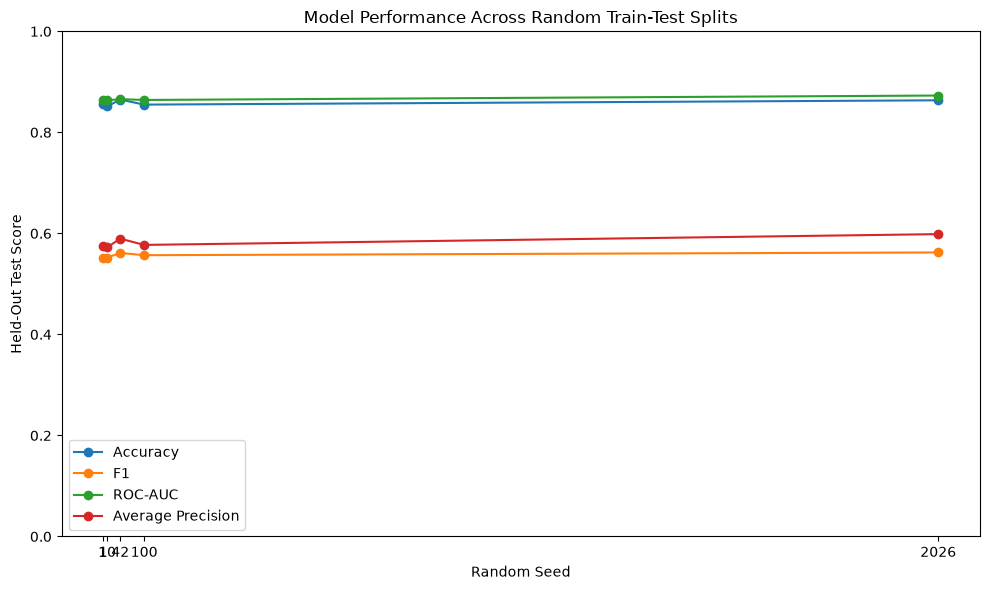

In [87]:
seed_plot_data = seed_results.set_index(
    "Random Seed"
)

plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "F1",
    "ROC-AUC",
    "Average Precision"
]:

    plt.plot(
        seed_plot_data.index,
        seed_plot_data[metric],
        marker="o",
        label=metric
    )

plt.xlabel(
    "Random Seed"
)

plt.ylabel(
    "Held-Out Test Score"
)

plt.title(
    "Model Performance Across Random Train-Test Splits"
)

plt.xticks(
    random_seeds
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

plt.show()

## Repeated Stratified Cross-Validation

A single five-fold cross-validation run provides one estimate of performance variation across folds.

Repeated stratified cross-validation extends this analysis by repeating the five-fold process multiple times with different fold assignments.

This analysis uses:

- 5 folds
- 10 repetitions
- 50 validation evaluations in total

The final Random Forest configuration is evaluated without hyperparameter tuning.

The following metrics are recorded:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Average Precision

The mean, standard deviation, minimum, and maximum are reported.

This provides a broader estimate of how performance varies across different training and validation subsets.

In [88]:
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

repeated_cv_results = cross_validate(
    best_model,
    X_full,
    y_full,
    cv=repeated_cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    n_jobs=-1
)

In [89]:
repeated_cv_scores = pd.DataFrame({
    "Accuracy":
    repeated_cv_results[
        "test_accuracy"
    ],

    "Precision":
    repeated_cv_results[
        "test_precision"
    ],

    "Recall":
    repeated_cv_results[
        "test_recall"
    ],

    "F1":
    repeated_cv_results[
        "test_f1"
    ],

    "ROC-AUC":
    repeated_cv_results[
        "test_roc_auc"
    ],

    "Average Precision":
    repeated_cv_results[
        "test_average_precision"
    ]
})

print(
    "Number of validation evaluations:",
    len(repeated_cv_scores)
)

repeated_cv_scores.head()

Number of validation evaluations: 50


,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,0.854394,0.509865,0.598051,0.550448,0.865567,0.594796
1,0.864742,0.545238,0.557856,0.551475,0.864554,0.566095
2,0.851126,0.500978,0.622871,0.555315,0.867464,0.584646
3,0.867647,0.553265,0.587591,0.569912,0.868372,0.579611
4,0.852578,0.505274,0.582725,0.541243,0.857960,0.577224


In [90]:
repeated_cv_summary = pd.DataFrame({
    "Metric":
    repeated_cv_scores.columns,

    "Mean": [
        repeated_cv_scores[
            metric
        ].mean()

        for metric
        in repeated_cv_scores.columns
    ],

    "Standard Deviation": [
        repeated_cv_scores[
            metric
        ].std(ddof=0)

        for metric
        in repeated_cv_scores.columns
    ],

    "Minimum": [
        repeated_cv_scores[
            metric
        ].min()

        for metric
        in repeated_cv_scores.columns
    ],

    "Maximum": [
        repeated_cv_scores[
            metric
        ].max()

        for metric
        in repeated_cv_scores.columns
    ]
})

repeated_cv_summary.round(3)

,Metric,Mean,Standard Deviation,Minimum,Maximum
0,Accuracy,0.858,0.006,0.845,0.868
1,Precision,0.523,0.017,0.484,0.553
2,Recall,0.593,0.019,0.558,0.644
3,F1,0.555,0.012,0.528,0.581
4,ROC-AUC,0.867,0.005,0.857,0.880
5,Average Precision,0.579,0.014,0.552,0.605


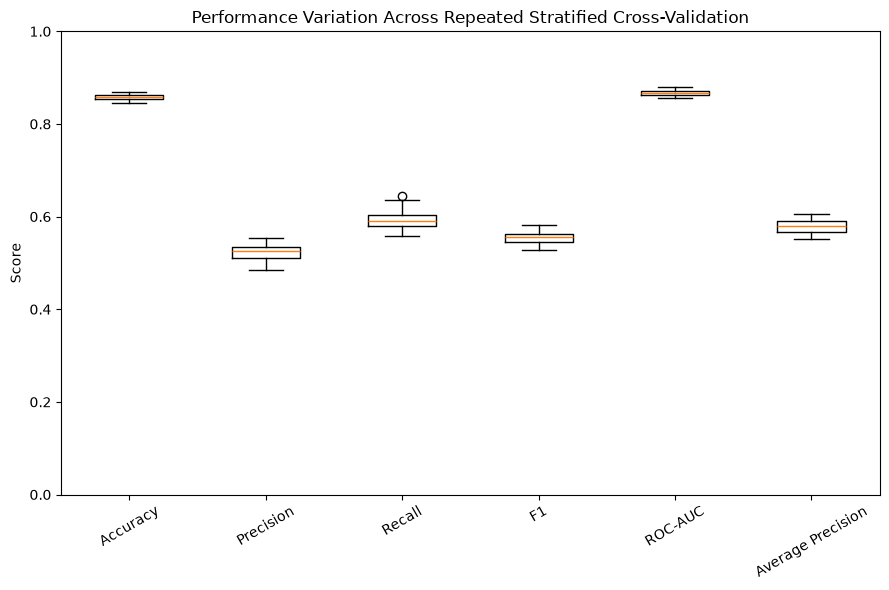

In [91]:
plt.figure(figsize=(9, 6))

plt.boxplot(
    [
        repeated_cv_scores["Accuracy"],
        repeated_cv_scores["Precision"],
        repeated_cv_scores["Recall"],
        repeated_cv_scores["F1"],
        repeated_cv_scores["ROC-AUC"],
        repeated_cv_scores["Average Precision"]
    ],
    tick_labels=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision"
]
)

plt.ylabel(
    "Score"
)

plt.title(
    "Performance Variation Across Repeated Stratified Cross-Validation"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

## Training, Cross-Validation, and Held-Out Test Performance

Model performance is compared across three stages:

Training performance
        ↓
Cross-validation performance
        ↓
Held-out test performance

The comparison helps identify potential overfitting.

A large difference between training and cross-validation performance may indicate that the model fits the training data substantially better than unseen validation data.

A difference between cross-validation and held-out test performance may reflect variation caused by the particular held-out test partition.

The held-out test set remains separate from the repeated cross-validation analysis.

The following generalization gaps are calculated:

- Training F1 − Cross-validation F1
- Cross-validation F1 − Test F1
- Training F1 − Test F1

The same comparison is also performed for ROC-AUC and Average Precision.

In [92]:
X_train_original, X_test_original, y_train_original, y_test_original = (
    train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=42
    )
)

model_for_comparison = joblib.load(
    "../models/random_forest.joblib"
)

model_for_comparison.fit(
    X_train_original,
    y_train_original
)

training_predictions = (
    model_for_comparison.predict(
        X_train_original
    )
)

training_probabilities = (
    model_for_comparison.predict_proba(
        X_train_original
    )[:, 1]
)

test_predictions = (
    model_for_comparison.predict(
        X_test_original
    )
)

test_probabilities = (
    model_for_comparison.predict_proba(
        X_test_original
    )[:, 1]
)

In [93]:
training_metrics = {
    "F1": f1_score(
        y_train_original,
        training_predictions,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_train_original,
        training_probabilities
    ),

    "Average Precision":
    average_precision_score(
        y_train_original,
        training_probabilities
    )
}

test_metrics = {
    "F1": f1_score(
        y_test_original,
        test_predictions,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test_original,
        test_probabilities
    ),

    "Average Precision":
    average_precision_score(
        y_test_original,
        test_probabilities
    )
}

cv_metrics = {
    "F1":
    repeated_cv_scores["F1"].mean(),

    "ROC-AUC":
    repeated_cv_scores["ROC-AUC"].mean(),

    "Average Precision":
    repeated_cv_scores[
        "Average Precision"
    ].mean()
}

performance_comparison = pd.DataFrame({
    "Metric": [
        "F1",
        "ROC-AUC",
        "Average Precision"
    ],

    "Training": [
        training_metrics["F1"],
        training_metrics["ROC-AUC"],
        training_metrics[
            "Average Precision"
        ]
    ],

    "Repeated CV Mean": [
        cv_metrics["F1"],
        cv_metrics["ROC-AUC"],
        cv_metrics[
            "Average Precision"
        ]
    ],

    "Held-Out Test": [
        test_metrics["F1"],
        test_metrics["ROC-AUC"],
        test_metrics[
            "Average Precision"
        ]
    ]
})

performance_comparison.round(3)

,Metric,Training,Repeated CV Mean,Held-Out Test
0,F1,0.896,0.555,0.561
1,ROC-AUC,0.998,0.867,0.866
2,Average Precision,0.989,0.579,0.590


In [94]:
generalization_gaps = pd.DataFrame({
    "Metric": [
        "F1",
        "ROC-AUC",
        "Average Precision"
    ],

    "Training − CV": [
        training_metrics["F1"]
        - cv_metrics["F1"],

        training_metrics["ROC-AUC"]
        - cv_metrics["ROC-AUC"],

        training_metrics[
            "Average Precision"
        ]
        - cv_metrics[
            "Average Precision"
        ]
    ],

    "CV − Test": [
        cv_metrics["F1"]
        - test_metrics["F1"],

        cv_metrics["ROC-AUC"]
        - test_metrics["ROC-AUC"],

        cv_metrics[
            "Average Precision"
        ]
        - test_metrics[
            "Average Precision"
        ]
    ],

    "Training − Test": [
        training_metrics["F1"]
        - test_metrics["F1"],

        training_metrics["ROC-AUC"]
        - test_metrics["ROC-AUC"],

        training_metrics[
            "Average Precision"
        ]
        - test_metrics[
            "Average Precision"
        ]
    ]
})

generalization_gaps.round(3)

,Metric,Training − CV,CV − Test,Training − Test
0,F1,0.341,-0.006,0.335
1,ROC-AUC,0.131,0.001,0.132
2,Average Precision,0.410,-0.011,0.399


## Subgroup Performance

Overall performance can conceal weaknesses in specific regions of the astronomical parameter space.

To investigate this possibility, the held-out test set is divided into scientifically interpretable subgroups based on host-star properties:

- Stellar effective temperature (`st_teff`)
- Stellar radius (`st_rad`)
- Stellar metallicity (`st_met`)

For each feature, observations are divided into lower and higher groups using the median value calculated from the training data only.

The training-derived boundaries are then applied unchanged to the held-out test set.

This prevents the test set from influencing the subgroup definitions.

For each subgroup, the following are calculated where valid:

- Number of observations
- Class distribution
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Average Precision
- Error rate
- Mean predicted gas-giant probability

Metrics such as ROC-AUC and Average Precision require both classes to be present within a subgroup. If a subgroup contains only one class, these metrics are reported as unavailable rather than calculated.

In [95]:
X_train_subgroup, X_test_subgroup, y_train_subgroup, y_test_subgroup = (
    train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=42
    )
)

subgroup_model = joblib.load(
    "../models/random_forest.joblib"
)

subgroup_model.fit(
    X_train_subgroup,
    y_train_subgroup
)

subgroup_predictions = (
    subgroup_model.predict(
        X_test_subgroup
    )
)

subgroup_probabilities = (
    subgroup_model.predict_proba(
        X_test_subgroup
    )[:, 1]
)

In [96]:
subgroup_thresholds = {
    feature: X_train_subgroup[
        feature
    ].median()

    for feature in [
        "st_teff",
        "st_rad",
        "st_met"
    ]
}

subgroup_thresholds

{'st_teff': np.float64(5641.0),
 'st_rad': np.float64(0.937),
 'st_met': np.float64(-0.02)}

In [97]:
subgroup_data = X_test_subgroup.copy()

subgroup_data["Actual"] = (
    y_test_subgroup.values
)

subgroup_data["Predicted"] = (
    subgroup_predictions
)

subgroup_data[
    "Gas Giant Probability"
] = subgroup_probabilities

subgroup_data["Correct"] = (
    subgroup_data["Actual"]
    ==
    subgroup_data["Predicted"]
)

for feature, threshold in subgroup_thresholds.items():

    subgroup_data[
        f"{feature}_Group"
    ] = np.where(
        subgroup_data[feature]
        < threshold,

        "Lower",

        "Higher"
    )

subgroup_data.head()

,st_teff,st_rad,st_met,Actual,Predicted,Gas Giant Probability,Correct,st_teff_Group,st_rad_Group,st_met_Group
26110,5683.0,2.100,0.223,1,1,1.00,True,Higher,Higher,Higher
19246,5757.0,0.881,-0.060,0,0,0.00,True,Higher,Lower,Lower
184,6245.0,0.981,-0.300,0,0,0.01,True,Higher,Higher,Lower
3924,5767.0,0.851,-0.180,0,0,0.00,True,Higher,Lower,Lower
4614,5840.0,1.626,0.188,1,0,0.29,False,Higher,Higher,Higher


### Subgroup Metric Calculation

The following function calculates subgroup performance.

ROC-AUC and Average Precision are only calculated when both target classes are present in the subgroup.

This is important because ranking metrics are not defined meaningfully when a subgroup contains only one class.

In [98]:
def evaluate_subgroup(
    subgroup
):

    y_true = subgroup["Actual"]

    y_pred = subgroup["Predicted"]

    y_prob = subgroup[
        "Gas Giant Probability"
    ]

    result = {
        "Number of Observations":
        len(subgroup),

        "Gas Giant Count":
        (y_true == 1).sum(),

        "Non-Gas Giant Count":
        (y_true == 0).sum(),

        "Gas Giant Proportion":
        y_true.mean(),

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "Precision":
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1":
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Error Rate":
        1 - accuracy_score(
            y_true,
            y_pred
        ),

        "Mean Gas Giant Probability":
        y_prob.mean()
    }

    if y_true.nunique() == 2:

        result["ROC-AUC"] = (
            roc_auc_score(
                y_true,
                y_prob
            )
        )

        result[
            "Average Precision"
        ] = (
            average_precision_score(
                y_true,
                y_prob
            )
        )

    else:

        result["ROC-AUC"] = np.nan

        result[
            "Average Precision"
        ] = np.nan

    return result

In [99]:
subgroup_results = []

for feature in [
    "st_teff",
    "st_rad",
    "st_met"
]:

    group_column = (
        f"{feature}_Group"
    )

    for group in [
        "Lower",
        "Higher"
    ]:

        subgroup = subgroup_data[
            subgroup_data[
                group_column
            ]
            ==
            group
        ]

        metrics = evaluate_subgroup(
            subgroup
        )

        metrics["Feature"] = feature

        metrics["Group"] = group

        metrics["Training Boundary"] = (
            subgroup_thresholds[
                feature
            ]
        )

        subgroup_results.append(
            metrics
        )

subgroup_results = pd.DataFrame(
    subgroup_results
)

subgroup_results = subgroup_results[
    [
        "Feature",
        "Group",
        "Training Boundary",
        "Number of Observations",
        "Gas Giant Count",
        "Non-Gas Giant Count",
        "Gas Giant Proportion",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision",
        "Error Rate",
        "Mean Gas Giant Probability"
    ]
]

subgroup_results.round(3)

,Feature,Group,Training Boundary,Number of Observations,Gas Giant Count,Non-Gas Giant Count,Gas Giant Proportion,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Error Rate,Mean Gas Giant Probability
0,st_teff,Lower,5641.000,2653,292,2361,0.110,0.888,0.492,0.527,0.509,0.861,0.517,0.112,0.167
1,st_teff,Higher,5641.000,2855,530,2325,0.186,0.843,0.574,0.608,0.590,0.861,0.633,0.157,0.259
2,st_rad,Lower,0.937,2770,240,2530,0.087,0.903,0.435,0.404,0.419,0.831,0.406,0.097,0.130
3,st_rad,Higher,0.937,2738,582,2156,0.213,0.827,0.582,0.651,0.615,0.864,0.671,0.173,0.300
4,st_met,Lower,-0.020,1857,137,1720,0.074,0.939,0.575,0.642,0.607,0.925,0.629,0.061,0.112
5,st_met,Higher,-0.020,3651,685,2966,0.188,0.827,0.538,0.566,0.552,0.829,0.581,0.173,0.267


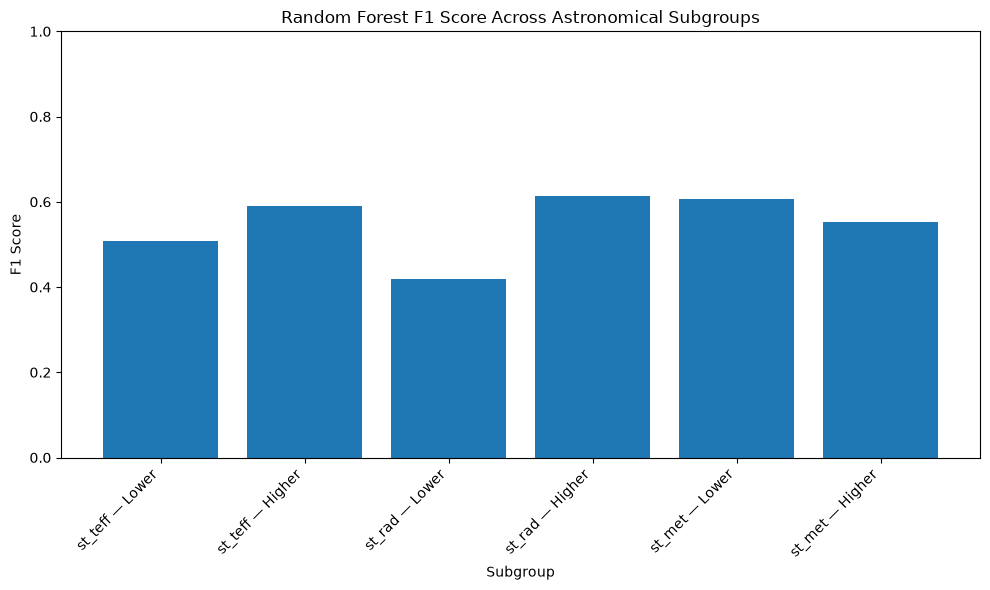

In [100]:
subgroup_plot = subgroup_results.copy()

subgroup_plot[
    "Label"
] = (
    subgroup_plot["Feature"]
    + " — "
    + subgroup_plot["Group"]
)

plt.figure(figsize=(10, 6))

plt.bar(
    subgroup_plot["Label"],
    subgroup_plot["F1"]
)

plt.xlabel(
    "Subgroup"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Random Forest F1 Score Across Astronomical Subgroups"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

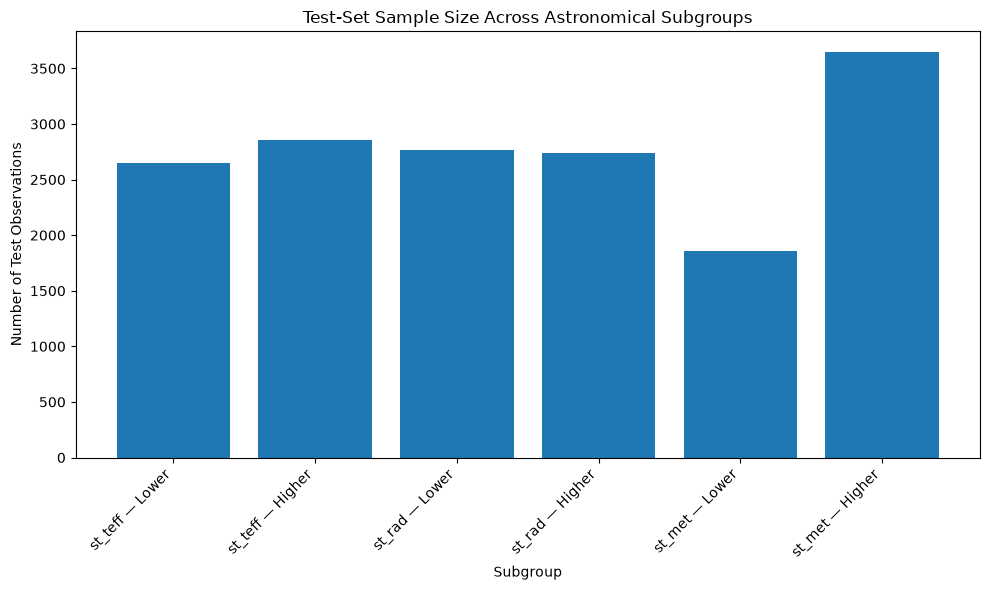

In [101]:
plt.figure(figsize=(10, 6))

plt.bar(
    subgroup_plot["Label"],
    subgroup_plot[
        "Number of Observations"
    ]
)

plt.xlabel(
    "Subgroup"
)

plt.ylabel(
    "Number of Test Observations"
)

plt.title(
    "Test-Set Sample Size Across Astronomical Subgroups"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

## Summary

This notebook evaluated the generalization and subgroup robustness of the fixed Random Forest model.

First, random-seed robustness analysis examined whether performance depended strongly on a particular stratified train-test split.

Second, repeated stratified cross-validation provided a broader estimate of performance variability than a single five-fold cross-validation run.

Third, training, cross-validation, and held-out test performance were compared to quantify potential generalization gaps.

Finally, subgroup analysis examined whether performance was consistent across lower and higher regions of stellar effective temperature, stellar radius, and stellar metallicity.

The subgroup boundaries were calculated using the training data only and then applied to the held-out test set.

Together, these analyses help determine whether the model's overall performance is stable across different data partitions and whether the reported performance may conceal weaknesses in particular regions of the astronomical parameter space.

These analyses do not establish that the model will generalize to all exoplanets. The results remain dependent on the distribution, quality, and selection effects of the dataset used in this study.

In [102]:
final_generalization_summary = pd.DataFrame({
    "Analysis": [
        "Random-seed mean F1",
        "Random-seed F1 standard deviation",
        "Repeated CV mean F1",
        "Repeated CV F1 standard deviation",
        "Training F1",
        "Held-out test F1",
        "Training − CV F1 gap",
        "CV − Test F1 gap"
    ],

    "Result": [
        seed_results["F1"].mean(),

        seed_results["F1"].std(
            ddof=0
        ),

        repeated_cv_scores[
            "F1"
        ].mean(),

        repeated_cv_scores[
            "F1"
        ].std(
            ddof=0
        ),

        training_metrics[
            "F1"
        ],

        test_metrics[
            "F1"
        ],

        generalization_gaps.loc[
            generalization_gaps[
                "Metric"
            ]
            ==
            "F1",
            "Training − CV"
        ].iloc[0],

        generalization_gaps.loc[
            generalization_gaps[
                "Metric"
            ]
            ==
            "F1",
            "CV − Test"
        ].iloc[0]
    ]
})

final_generalization_summary.round(3)

,Analysis,Result
0,Random-seed mean F1,0.557
1,Random-seed F1 standard deviation,0.004
2,Repeated CV mean F1,0.555
3,Repeated CV F1 standard deviation,0.012
4,Training F1,0.896
5,Held-out test F1,0.561
6,Training − CV F1 gap,0.341
7,CV − Test F1 gap,-0.006
